In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy import stats

from func.configs import CONTEXT_LEN

plt.rcParams["font.family"] = "Arial"
mpl.rcParams["xtick.labelsize"] = 8
mpl.rcParams["ytick.labelsize"] = 8
mpl.rcParams["axes.labelsize"]  = 10
mpl.rcParams["axes.titlesize"] = 10
mpl.rcParams["legend.fontsize"] = 10

# Parameters
results_root = "./results/LightGBM_iterate-context_sub"

x_ticklabels = [
    "0", "20", "40", "60", "80",
    "100", "200", "400", "600", "800",
    "1k", "2k", "4k", "6k", "8k", "10k"
]

LINE_COLORS = {"Acoustics": "#1f77b4", "Speech": "#d62728"}
BOX_COLORS  = {"Acoustics": "#aec7e8", "Speech": "#f7b6b2"}

ALPHA = 0.05

SUBS = [
    "sub-01", "sub-02", "sub-03", "sub-04", "sub-05",
    "sub-06", "sub-07", "sub-10", "sub-11", "sub-12"
]

In [2]:
# -------------------------
# Loading helpers
# -------------------------
def load_results(func_handle=np.max):

    results_dir = os.path.join(results_root, "char-level")
    r_obs_list = list()
    for idx, context_len in enumerate(CONTEXT_LEN):
        for sub in SUBS:
            r_obs_acoustics = func_handle(np.load(os.path.join(results_dir, f"{sub}/whisper-acoustics_context-{context_len}_r-obs.npy")))
            r_obs_speech = func_handle(np.load(os.path.join(results_dir, f"{sub}/whisper-speech_context-{context_len}_r-obs.npy")))
            r_obs_list.append({"ContextLen": context_len, "R": r_obs_acoustics, "Group": "Acoustics", "Sid": sub})
            r_obs_list.append({"ContextLen": context_len, "R": r_obs_speech, "Group": "Speech", "Sid": sub})
    df_char = pd.DataFrame(r_obs_list)

    results_dir = os.path.join(results_root, "word-level")
    r_obs_list = list()
    for idx, context_len in enumerate(CONTEXT_LEN):
        for sub in SUBS:
            r_obs_acoustics = func_handle(np.load(os.path.join(results_dir, f"{sub}/whisper-acoustics_context-{context_len}_r-obs.npy")))
            r_obs_speech = func_handle(np.load(os.path.join(results_dir, f"{sub}/whisper-speech_context-{context_len}_r-obs.npy")))
            r_obs_list.append({"ContextLen": context_len, "R": r_obs_acoustics, "Group": "Acoustics", "Sid": sub})
            r_obs_list.append({"ContextLen": context_len, "R": r_obs_speech, "Group": "Speech", "Sid": sub})
    df_word = pd.DataFrame(r_obs_list)

    return df_char, df_word


# -------------------------
# Stats helpers
# -------------------------
def check_normal(func_handle=np.max):
    features = ["speech", "acoustics"]

    results_dir = os.path.join(results_root, "char-level")
    for feature in features:
        for idx, context_len in enumerate(CONTEXT_LEN):
            r_context = list()
            for sub in SUBS:
                r = func_handle(np.load(os.path.join(results_dir, f"{sub}/whisper-{feature}_context-{context_len}_r-obs.npy")))
                r_context.append(r)
            r_context = np.asarray(r_context)
            shapiro_stat, shapiro_p = stats.shapiro(r_context)
            results = "数据服从正态分布" if shapiro_p > 0.05 else "数据不服从正态分布"
            print(f"Char-Level, Feature: {feature}, Context Length: {context_len}ms, P_val: {shapiro_p:.3f}, Results: {results}")
    
    results_dir = os.path.join(results_root, "word-level")
    for feature in features:
        for idx, context_len in enumerate(CONTEXT_LEN):
            r_context = list()
            for sub in SUBS:
                r = func_handle(np.load(os.path.join(results_dir, f"{sub}/whisper-{feature}_context-{context_len}_r-obs.npy")))
                r_context.append(r)
            r_context = np.asarray(r_context)
            shapiro_stat, shapiro_p = stats.shapiro(r_context)
            results = "数据服从正态分布" if shapiro_p > 0.05 else "数据不服从正态分布"
            print(f"Word-Level, Feature: {feature}, Context Length: {context_len}ms, P_val: {shapiro_p:.3f}, Results: {results}")


# -------------------------
# Plotting helpers
# -------------------------
def plot_box(ax,
             df,
             x_col="ContextLen",
             y_col="R",
             group_col="Group",
             groups=("Acoustics", "Speech"),
             x_ticklabels=None,
             title=None,
             box_width=0.3,
             offset=0.2,
             line_colors=None,
             box_colors=None
):
    """
    Plot the following on a given Axes:
        1) Mean curves (lineplot) for each group
        2) Box plots for each x-axis position and each group

    Parameters
    ----
    ax : matplotlib.axes.Axes
        The coordinate axis objects to be drawn.
    df : pd.DataFrame
        The data table.
    x_col : str
        The column name of the horizontal axis variable (e.g., "ContextLen").
    y_col : str
        The column name of the vertical axis variable (e.g., "R").
    group_col : str
        Grouping variable column name (e.g., "Group").
    groups : sequence
        The groups and their order to be drawn (e.g., ["Acoustics", "Speech"]).
    x_ticklabels : list or None
        Custom x-axis tick labels; if None, use the string unique_x.
    title : str or None
        Figure title.
    box_width : float
        Box plot width.
    offset : float
        Left and right offsets of box plots in the x-direction for different groups.
    """
    if line_colors is None:
        line_colors = LINE_COLORS
    if box_colors is None:
        box_colors = BOX_COLORS

    df = df.copy()
    df = df[df[group_col].isin(groups)]

    unique_x = sorted(df[x_col].unique())
    x_map = {val: i for i, val in enumerate(unique_x)}
    df = df.copy()
    df["x_idx"] = df[x_col].map(x_map)

    df_mean = (
        df.groupby([x_col, group_col])[y_col]
        .mean()
        .reset_index()
    )
    df_mean["x_idx"] = df_mean[x_col].map(x_map)

    signif_dict = {}
    for group in groups:
        df_g = df[df[group_col] == group]
        wide = df_g.pivot_table(
            index="Sid",
            columns=x_col,
            values=y_col,
            aggfunc="mean"
        )

        signif = {}
        for c in unique_x:
            if c == 0:
                signif[c] = False
                continue
            if c not in wide.columns:
                signif[c] = False
                continue
            paired = wide[[0, c]].dropna()
            if len(paired) < 2:
                signif[c] = False
                continue
            
            x_vals = paired[c].values
            y_vals = paired[0].values

            tstat, p = stats.ttest_rel(x_vals, y_vals, alternative="greater")

            if np.isnan(p):
                signif[c] = False
            else:
                signif[c] = (p < ALPHA)

        signif_dict[group] = signif

    for group in groups:
        color = line_colors[group]
        sub_mean = df_mean[df_mean[group_col] == group].sort_values(x_col)

        xs = sub_mean["x_idx"].values
        ys = sub_mean[y_col].values
        cs = sub_mean[x_col].values
        
        ax.plot(xs, ys, color=color, linewidth=2.2, zorder=9)

        for x_i, y_i, c_i in zip(xs, ys, cs):
            is_sig = signif_dict[group].get(c_i, False)
            if is_sig:
                ax.plot(
                    x_i, y_i, marker="o", markersize=4.5, color=color,
                    markerfacecolor=color, markeredgecolor=color,
                    linestyle="None", zorder=10, label=None
                )
            else:
                ax.plot(
                    x_i, y_i, marker="o", markersize=4.5, color=color,
                    markerfacecolor="white", markeredgecolor=color, linewidth=1.0,
                    linestyle="None", zorder=10, label=None
                )
    
    if not hasattr(ax, "_legend_added"):
        for group in groups:
            color = line_colors[group]
            ax.plot(
                [], [],
                marker="o",
                markersize=5,
                color=color,
                markerfacecolor=color,
                linestyle="-",
                linewidth=2.2,
                label=group
            )
        ax._legend_added = True

    for i, group in enumerate(groups):
        subset = df[df[group_col] == group]
        color = box_colors[group]

        if len(groups) == 2:
            pos_shift = -offset if i == 0 else offset
        else:
            pos_shift = (i - (len(groups) - 1) / 2) * (
                2 * offset / max(1, len(groups) - 1)
            )

        plot_data = []
        plot_positions = []

        for x_val in unique_x:
            data = subset[subset[x_col] == x_val][y_col].values
            if len(data) > 0:
                plot_data.append(data)
                plot_positions.append(x_map[x_val] + pos_shift)

        if len(plot_data) == 0:
            continue

        ax.boxplot(
            plot_data,
            positions=plot_positions,
            widths=box_width,
            patch_artist=True,
            manage_ticks=False,
            boxprops=dict(facecolor=color, alpha=0.35,
                          edgecolor="gray", linewidth=0.8),
            medianprops=dict(color=color, linewidth=1.4),
            whiskerprops=dict(color="gray", linewidth=0.8),
            capprops=dict(color="gray", linewidth=0.8),
            showfliers=False
        )

    ax.set_xticks(range(len(unique_x)))
    if x_ticklabels is None:
        ax.set_xticklabels([str(v) for v in unique_x], rotation=45)
    else:
        ax.set_xticklabels(x_ticklabels, rotation=45)

    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if title:
        ax.set_title(title, pad=10)

In [3]:
# -------------------------
# Check for normality
# -------------------------
print("="*14 + "Maximum R-value" + "="*14)
check_normal(func_handle=np.max)
print("="*14 + "Mean R-value" + "="*14)
check_normal(func_handle=np.mean)

==============Maximum R-value==============
Char-Level, Feature: speech, Context Length: 0ms, P_val: 0.387, Results: 数据服从正态分布
Char-Level, Feature: speech, Context Length: 20ms, P_val: 0.195, Results: 数据服从正态分布
Char-Level, Feature: speech, Context Length: 40ms, P_val: 0.282, Results: 数据服从正态分布
Char-Level, Feature: speech, Context Length: 60ms, P_val: 0.227, Results: 数据服从正态分布
Char-Level, Feature: speech, Context Length: 80ms, P_val: 0.400, Results: 数据服从正态分布
Char-Level, Feature: speech, Context Length: 100ms, P_val: 0.333, Results: 数据服从正态分布
Char-Level, Feature: speech, Context Length: 200ms, P_val: 0.252, Results: 数据服从正态分布
Char-Level, Feature: speech, Context Length: 400ms, P_val: 0.363, Results: 数据服从正态分布
Char-Level, Feature: speech, Context Length: 600ms, P_val: 0.420, Results: 数据服从正态分布
Char-Level, Feature: speech, Context Length: 800ms, P_val: 0.369, Results: 数据服从正态分布
Char-Level, Feature: speech, Context Length: 1000ms, P_val: 0.386, Results: 数据服从正态分布
Char-Level, Feature: speech, Context 

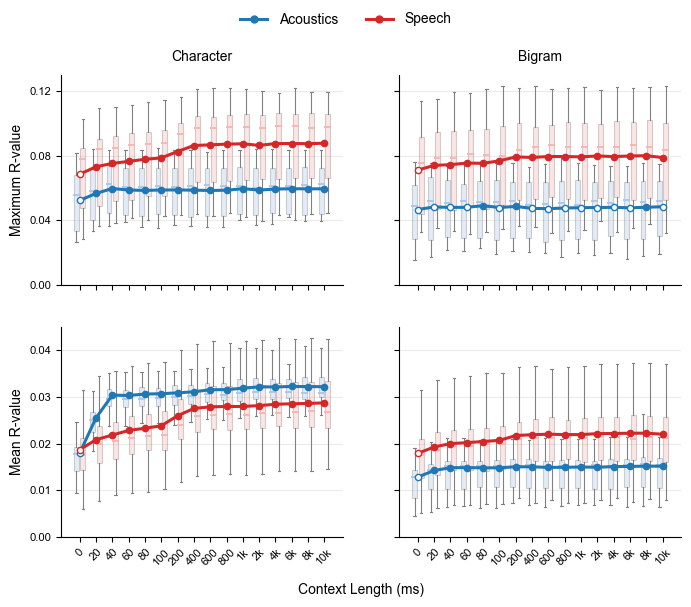

In [4]:
# -------------------------
# Display in Paper
# -------------------------
fig, [(ax_char_max, ax_word_max), (ax_char_mean, ax_word_mean)] = plt.subplots(
    2, 2, 
    figsize=(8, 6), 
    sharex=True,
    sharey="row"
)

# Maximum R
df_char, df_word = load_results(func_handle=np.max)

plot_box(ax_char_max, df_char, title="Character")
plot_box(ax_word_max, df_word, title="Bigram")

# Mean R
df_char, df_word = load_results(func_handle=np.mean)

plot_box(ax_char_mean, df_char, title=None, x_ticklabels=x_ticklabels)
plot_box(ax_word_mean, df_word, title=None, x_ticklabels=x_ticklabels)

ax_char_max.set_ylabel("Maximum R-value")
ax_char_mean.set_ylabel("Mean R-value")
ax_word_max.tick_params(labelleft=False)
ax_word_mean.tick_params(labelleft=False)
for ax in [ax_char_max, ax_word_max]:
    ax.set_ylim(0, 0.13)
    ax.yaxis.set_major_locator(plt.MaxNLocator(4))
for ax in [ax_char_mean, ax_word_mean]:
    ax.set_ylim(0, 0.045)
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))

handles, labels = ax_char_max.get_legend_handles_labels()
for ax in [ax_char_max, ax_word_max, ax_char_mean, ax_word_mean]:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    borderaxespad=0.5
)

fig.supxlabel("Context Length (ms)", fontsize=10)

plt.show()